# Logistic Regression classifier for letter recognition

**Task:** predict one of 26 uppercase letters (A–Z) from 16 numeric, image-derived features (UCI Letter Recognition dataset). This notebook trains one model family, **multinomial Logistic Regression**, in several varieties: different preprocessing branches (scaling, feature selection, PCA, polynomial features) and different regularization strengths `C`. It uses the same cleaning and stratified 80/20 split as the group preprocessing notebook, so results are comparable with the other members' models.


## 1. Libraries and reproducibility

`pandas`/`numpy` manage the data, `scikit-learn` provides preprocessing, `LogisticRegression`, cross-validation and metrics, and `matplotlib` draws the plots. `RANDOM_STATE = 42` fixes the split and any randomness so the experiment is repeatable.

In [ ]:
from pathlib import Path
from functools import partial

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


## 2. Dataset and problem

The notebook uses a local `letter-recognition.data` file when it is found (next to the notebook, or in `data/raw/`), and otherwise downloads the UCI CSV, so it also runs in Colab without a manual upload. UCI names the target `lettr`; it is renamed to `letter` here. Each row is one letter sample: 16 integer shape measurements (statistical moments and edge counts scaled to 0–15) and the letter to predict. The printed shape, missing-value count and number of classes are basic data checks.

In [ ]:
UCI_CSV = "https://archive.ics.uci.edu/static/public/59/data.csv"

columns = [
    "letter", "x-box", "y-box", "width", "high", "onpix",
    "x-bar", "y-bar", "x2bar", "y2bar", "xybar", "x2ybr",
    "xy2br", "x-ege", "xegvy", "y-ege", "yegvx"
]

local_candidates = [
    Path.cwd() / "letter-recognition.data",
    Path.cwd() / "data" / "raw" / "letter-recognition.data",
    Path.cwd().parent / "data" / "raw" / "letter-recognition.data",
]
local_file = next((p for p in local_candidates if p.exists()), None)
if local_file is not None:
    raw = pd.read_csv(local_file, header=None, names=columns)
    print("Source:", local_file)
else:
    raw = pd.read_csv(UCI_CSV).rename(columns={"lettr": "letter"})
    print("Source:", UCI_CSV)
raw = raw[columns]

print("Shape:", raw.shape)
print("Missing values:", raw.isna().sum().sum())
print("Classes:", raw["letter"].nunique())
display(raw.head())

Source: https://archive.ics.uci.edu/static/public/59/data.csv
Shape: (20000, 17)
Missing values: 0
Classes: 26


,letter,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


## 3. Cleaning, encoding and hold-out split

Exact duplicate rows are removed, the letters A–Z are encoded as 0–25, and a **stratified 80/20 split with seed 42** is made (identical to the group pipeline). Stratification keeps the class proportions the same in train and test. The test rows are not touched by any model search.

In [ ]:
data = raw.drop_duplicates().reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(data["letter"])
X = data.drop(columns="letter")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Duplicates removed:", len(raw) - len(data))
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Classes in train/test:", len(np.unique(y_train)), len(np.unique(y_test)))
print("First labels:", list(zip(encoder.classes_[:5], range(5))))

Duplicates removed: 1332
Train: (14934, 16) Test: (3734, 16)
Classes in train/test: 26 26
First labels: [('A', 0), ('B', 1), ('C', 2), ('D', 3), ('E', 4)]


## 4. Why Logistic Regression suits this problem

Logistic Regression is a classification model that learns one weight vector per class and converts the scores into class probabilities with the **softmax** function (multinomial logistic regression). The predicted letter is the one with the highest probability. It suits this dataset because:

- the target has 26 classes and scikit-learn's `LogisticRegression` handles multiclass problems directly;
- the inputs are 16 numeric features, so a linear model is fast to train and easy to interpret;
- it gives class probabilities, and it is a useful **linear baseline**: if a more flexible model (MLP, SVM) is much better, the letters are not linearly separable in the raw features.

Its main limitation is that decision boundaries are linear in the inputs, so letters that overlap in feature space (e.g. O/Q, H/R) are hard to separate. To test this, one of the preprocessing branches adds **polynomial (degree 2) features**, which lets the linear model use feature interactions.

**Parameters vs hyperparameters:** the learned weights and intercepts are *parameters*; the inverse regularization strength `C` (smaller = stronger L2 penalty), the number of iterations and the preprocessing branch are *hyperparameters* chosen before training.

**Baseline:** `StandardScaler` followed by `LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000)`. Scaling matters because the lbfgs optimiser converges faster and the L2 penalty treats all features equally only when they are on the same scale. The scaler is inside the pipeline so it is fitted only on training data.

In [ ]:
baseline = Pipeline([
    ("prep", StandardScaler()),
    ("logreg", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

## 5. Baseline validation

Five-fold stratified cross-validation trains the baseline five times on different training folds. **Macro F1** is used because it gives each of the 26 classes equal weight and balances precision and recall (the classes are nearly balanced, so accuracy is also reported later for reference). These are validation scores from the training partition, not final test scores.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_scores = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1,
)

print("Fold macro F1:", baseline_scores)
print("Mean macro F1:", baseline_scores.mean())
print("Standard deviation:", baseline_scores.std())

Fold macro F1: [0.75682535 0.75426594 0.758653   0.76296316 0.7633279 ]
Mean macro F1: 0.759207072174122
Standard deviation: 0.003506672404500507


## 6. Planned Logistic Regression varieties

The search compares **four preprocessing branches** and **five values of `C`**:

| Branch | Steps |
|---|---|
| Scaling (all 16 features) | `StandardScaler` |
| MI selection (10 features) + scaling | `SelectKBest(mutual_info_classif, k=10)` → `StandardScaler` |
| Scaling + PCA (12 components) | `StandardScaler` → `PCA(12)` |
| Scaling + polynomial degree 2 | `StandardScaler` → `PolynomialFeatures(2)` → `StandardScaler` (152 features) |

`C` ∈ {0.01, 0.1, 1, 10, 100}. That gives **20 candidate configurations** and **100 cross-validation fits** at five folds each. Every preprocessing step is inside the pipeline, so it is fitted only on each CV training fold and cannot leak validation data. All other settings match the baseline so the comparison focuses on these planned choices.

In [ ]:
mi_score = partial(
    mutual_info_classif,
    discrete_features=True,
    random_state=RANDOM_STATE,
)

preprocessors = [
    Pipeline([("scale", StandardScaler())]),
    Pipeline([
        ("select", SelectKBest(score_func=mi_score, k=10)),
        ("scale", StandardScaler()),
    ]),
    Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=12, random_state=RANDOM_STATE)),
    ]),
    Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scale2", StandardScaler()),
    ]),
]

search_pipeline = Pipeline([
    ("prep", "passthrough"),
    ("logreg", LogisticRegression(
        solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE,
    )),
])

parameter_grid = {
    "prep": preprocessors,
    "logreg__C": [0.01, 0.1, 1, 10, 100],
}

## 7. Hyperparameter tuning

`GridSearchCV` evaluates every candidate with the same five stratified folds and macro F1. `refit=True` retrains the best complete pipeline on the full training partition. The printed best score is a *validation* score used to select the model, not a test score.

In [ ]:
search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

search.fit(X_train, y_train)

print("Best CV macro F1:", search.best_score_)
print("Best settings:", search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV macro F1: 0.9369719128985009
Best settings: {'logreg__C': 1, 'prep': Pipeline(steps=[('scale', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('scale2', StandardScaler())])}


## 8. Compare every candidate

`mean_test_score` is the mean **validation-fold** macro F1; `mean_train_score` is the mean score on the training folds. A large train–validation gap suggests overfitting; `std_test_score` shows variation across folds. All 20 candidates are listed, not only the winner.

In [ ]:
results = pd.DataFrame(search.cv_results_)

def preprocessing_name(prep):
    steps = prep.named_steps
    if "poly" in steps:
        return "Scaling + polynomial (degree 2)"
    if "select" in steps:
        return "MI selection (10 features) + scaling"
    if "pca" in steps:
        return "Scaling + PCA (12 components)"
    return "Scaling (all 16 features)"

comparison = results[[
    "param_prep", "param_logreg__C",
    "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score",
]].copy()
comparison.insert(0, "preprocessing", comparison["param_prep"].map(preprocessing_name))
comparison = (comparison.drop(columns="param_prep")
              .rename(columns={"param_logreg__C": "C"})
              .sort_values("rank_test_score")
              .reset_index(drop=True))
pd.set_option("display.width", 200)
display(comparison)

,preprocessing,C,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,Scaling + polynomial (degree 2),1.00,0.979798,0.936972,0.000906,1
1,Scaling + polynomial (degree 2),10.00,0.995741,0.931378,0.003153,2
2,Scaling + polynomial (degree 2),100.00,0.998940,0.923347,0.003447,3
3,Scaling + polynomial (degree 2),0.10,0.947827,0.920963,0.002712,4
4,Scaling + polynomial (degree 2),0.01,0.879642,0.862453,0.003127,5
5,Scaling (all 16 features),1.00,0.767654,0.759207,0.003507,6
6,Scaling (all 16 features),100.00,0.766992,0.759142,0.004614,7
7,Scaling (all 16 features),10.00,0.767313,0.758888,0.004264,8
8,Scaling (all 16 features),0.10,0.757678,0.750430,0.006670,9
9,Scaling (all 16 features),0.01,0.712678,0.707161,0.006444,10


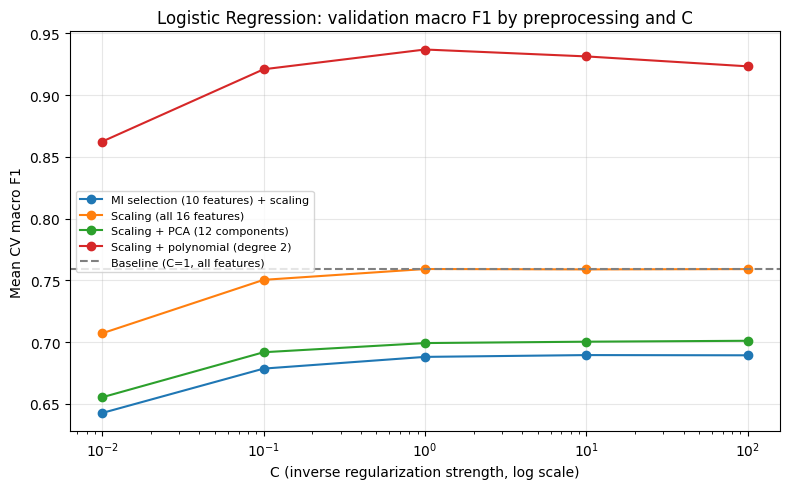

In [ ]:
# Visual comparison: validation macro F1 against C for each preprocessing branch.
fig, ax = plt.subplots(figsize=(8, 5))
for name, grp in comparison.groupby("preprocessing"):
    grp = grp.sort_values("C")
    ax.plot(grp["C"], grp["mean_test_score"], marker="o", label=name)
ax.axhline(baseline_scores.mean(), color="grey", linestyle="--", label="Baseline (C=1, all features)")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularization strength, log scale)")
ax.set_ylabel("Mean CV macro F1")
ax.set_title("Logistic Regression: validation macro F1 by preprocessing and C")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
cv_fig = fig
plt.show()

## 9. Final evaluation on held-out samples

After selection by CV, the refitted `best_estimator_` predicts the test partition **once**. Accuracy is the fraction of correctly classified letters; macro F1 weights every letter equally; weighted F1 accounts for class support. The test results were not used to change the chosen configuration.

In [ ]:
best_model = search.best_estimator_
pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, pred))
print("Test macro F1:", f1_score(y_test, pred, average="macro"))
print("Test weighted F1:", f1_score(y_test, pred, average="weighted"))

print(classification_report(
    y_test, pred, labels=np.arange(26),
    target_names=encoder.classes_, zero_division=0,
))

Test accuracy: 0.9413497589716122
Test macro F1: 0.9414728723456405
Test weighted F1: 0.9414960299365019
              precision    recall  f1-score   support

           A       0.99      0.95      0.97       151
           B       0.86      0.92      0.89       146
           C       0.94      0.93      0.93       142
           D       0.93      0.93      0.93       152
           E       0.92      0.95      0.94       145
           F       0.88      0.89      0.89       150
           G       0.89      0.90      0.90       149
           H       0.89      0.89      0.89       141
           I       0.97      0.90      0.94       105
           J       0.95      0.97      0.96       143
           K       0.93      0.94      0.93       144
           L       0.96      0.91      0.93       134
           M       0.97      0.96      0.97       146
           N       0.96      0.94      0.95       138
           O       0.96      0.94      0.95       144
           P       0.93      0

## 10. Error analysis

Rows of the confusion matrix are true letters, columns are predicted letters. A strong diagonal means correct classifications; off-diagonal cells show which letters are confused. The table lists the largest specific confusions.

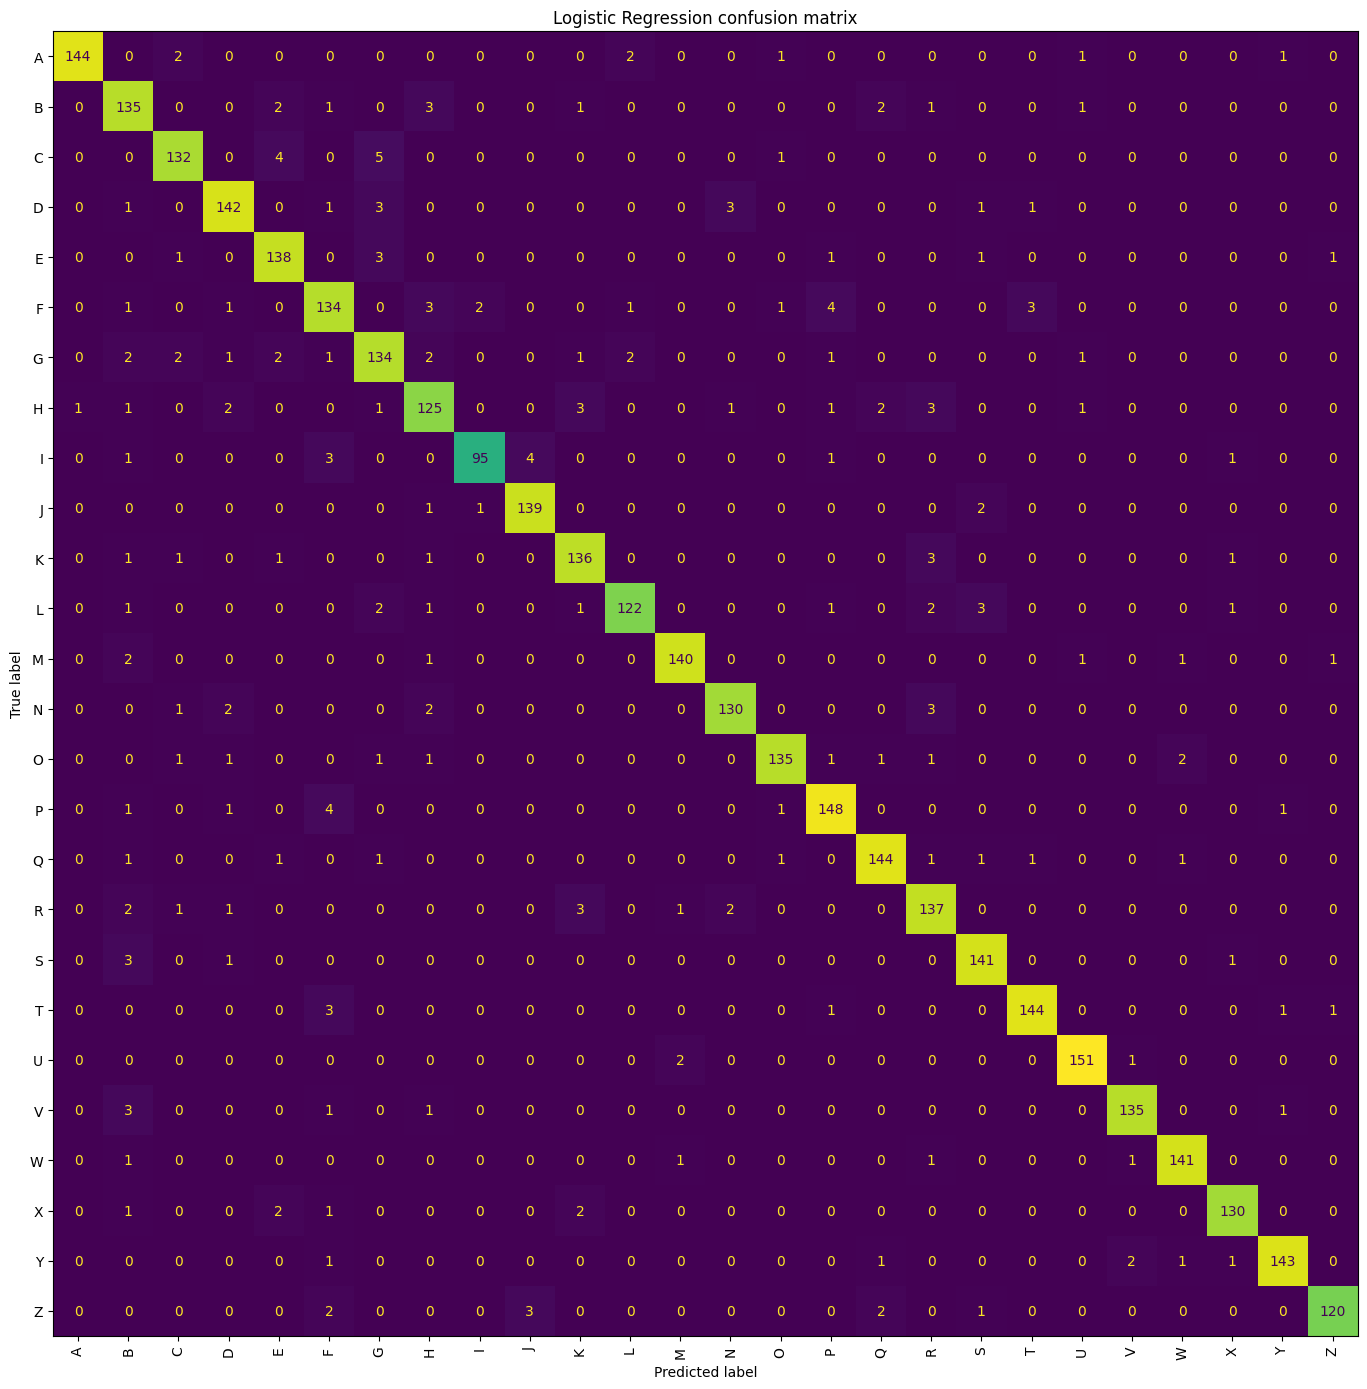

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=np.arange(26), display_labels=encoder.classes_,
    ax=ax, xticks_rotation=90, colorbar=False,
)
ax.set_title("Logistic Regression confusion matrix")
plt.tight_layout()
cm_fig = fig
plt.show()

In [ ]:
confusions = pd.crosstab(
    pd.Series(encoder.inverse_transform(y_test), name="actual"),
    pd.Series(encoder.inverse_transform(pred), name="predicted"),
)
for letter in encoder.classes_:
    confusions.loc[letter, letter] = 0

top_confusions = (
    confusions.stack().sort_values(ascending=False).head(10)
    .rename("count").reset_index()
)
display(top_confusions)

per_class = pd.Series(
    f1_score(y_test, pred, labels=np.arange(26), average=None),
    index=encoder.classes_, name="f1",
).sort_values()
print("Hardest letters (lowest F1):")
print(per_class.head(5).round(3).to_string())
print("Easiest letters (highest F1):")
print(per_class.tail(5).round(3).to_string())

,actual,predicted,count
0,C,G,5
1,C,E,4
2,I,J,4
3,P,F,4
4,F,P,4
5,K,R,3
6,B,H,3
7,T,F,3
8,S,B,3
9,E,G,3


Hardest letters (lowest F1):
H    0.887
F    0.887
B    0.891
G    0.896
R    0.916
Easiest letters (highest F1):
M    0.966
Y    0.966
W    0.969
A    0.973
U    0.974


## 11. Save results for demonstration

The comparison CSV, metrics CSV, fitted pipeline and plots are saved to a `results/outputs` folder next to the notebook. In Colab, download these files separately; downloading the notebook does not include them.

In [ ]:
output_dir = Path.cwd() / "results" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(output_dir / "logreg_cv_comparison.csv", index=False)
pd.DataFrame([{
    "baseline_cv_macro_f1": baseline_scores.mean(),
    "cv_macro_f1": search.best_score_,
    "test_accuracy": accuracy_score(y_test, pred),
    "test_macro_f1": f1_score(y_test, pred, average="macro"),
    "test_weighted_f1": f1_score(y_test, pred, average="weighted"),
    "train_rows": len(y_train),
    "test_rows": len(y_test),
    "cv_folds": cv.get_n_splits(),
    "candidates": len(results),
}]).to_csv(output_dir / "logreg_metrics.csv", index=False)
joblib.dump(best_model, output_dir / "logreg_best_pipeline.pkl")
cm_fig.savefig(output_dir / "logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
cv_fig.savefig(output_dir / "logreg_cv_comparison.png", dpi=150, bbox_inches="tight")

print("Saved comparison, metrics, fitted pipeline and plots to:", output_dir)

Saved comparison, metrics, fitted pipeline and plots to: /content/results/outputs


## 12. Conclusion, limitations and contribution to the group report

The cell below builds the numerical conclusion from the **current run** (winning branch, `C`, baseline vs tuned CV scores, train–validation gap, held-out metrics and the leading confusions), so the text never goes stale if the code or data change.

**Limitations**
- Logistic Regression is a *linear* classifier; letters with overlapping measurements are hard to separate unless nonlinear features (such as the polynomial branch) are added, and even then it may trail nonlinear models like an MLP or SVM.
- The features are measurements, not raw pixels, so this notebook does not show performance on arbitrary photographs or new handwriting.
- A train–CV gap indicates some overfitting, especially with weak regularization or many polynomial features.
- Only a limited grid was searched (4 preprocessing branches × 5 values of `C`, L2 penalty only); repeated CV, other penalties (L1/elastic net with `saga`), class weights or polynomial degree 3 could be explored.

**Improvements:** try feature interactions selectively, kernel/nonlinear models, and compare against the other group members' models on the same split.

**For the group report:** contribute the model rationale, pipeline and hyperparameters, CV comparison, test metrics, confusion findings and limitations. The group must still compare the best results of all six members' models and discuss challenges and expected behaviour.

**References:** [UCI Letter Recognition dataset](https://archive.ics.uci.edu/dataset/59/letter+recognition); [scikit-learn LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html); [scikit-learn GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

In [ ]:
from IPython.display import Markdown

winner = results.loc[search.best_index_]
branch = preprocessing_name(search.best_params_["prep"])
cv_gain = search.best_score_ - baseline_scores.mean()
train_gap = winner["mean_train_score"] - winner["mean_test_score"]
accuracy = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average="macro")
weighted_f1 = f1_score(y_test, pred, average="weighted")
leading_errors = ", ".join(
    f"{row.actual} → {row.predicted} ({row.count})"
    for row in top_confusions.head(3).itertuples(index=False)
)

display(Markdown(f"""**Current-run findings.** The search evaluated {len(results)} Logistic Regression
configurations with {cv.get_n_splits()} stratified folds each. The best branch was **{branch}** with
`C={search.best_params_['logreg__C']}`. Mean CV macro F1 was **{search.best_score_:.4f}**, versus
**{baseline_scores.mean():.4f}** for the baseline (difference: {cv_gain:+.4f}). The winner's mean
training-fold macro F1 was **{winner['mean_train_score']:.4f}**, a train–validation gap of **{train_gap:.4f}**.
On {len(y_test)} held-out rows, accuracy was **{accuracy:.4f}**, macro F1 **{macro_f1:.4f}** and
weighted F1 **{weighted_f1:.4f}**. Leading errors were {leading_errors}."""))

**Current-run findings.** The search evaluated 20 Logistic Regression
configurations with 5 stratified folds each. The best branch was **Scaling + polynomial (degree 2)** with
`C=1`. Mean CV macro F1 was **0.9370**, versus
**0.7592** for the baseline (difference: +0.1778). The winner's mean
training-fold macro F1 was **0.9798**, a train–validation gap of **0.0428**.
On 3734 held-out rows, accuracy was **0.9413**, macro F1 **0.9415** and
weighted F1 **0.9415**. Leading errors were C → G (5), C → E (4), I → J (4).